# Red coral — 1D latent dynamics (paper §5.5)

A 13-age-class coral population model compressed to a **1D latent space**. The latent Morse graph should be bistable, and the §5.5.1 success metric should place the two reference attractors `a0`, `a1` in distinct minimal Morse sets while the repeller `r` lands in a non-minimal one.

**Note on artifacts.** Brittany's preserved `train_500` checkpoints (the paper's basic run) are 0-byte in `replay_sources/coral`, so we replay the local retrain in `output/coral_data_scaling` at the same training size (`train_500`, `seed_0`). The histograms below come from the data CSVs and are unaffected.

In [1]:
from latentdynamics.replay import load_experiment, repo_path, show_image

exp = load_experiment(
    "coral_data_scaling",
    train_file="train_500",
    seed=0,
    output_dir="output/coral_data_scaling",
)
exp

ReplayExperiment(name='coral_data_scaling', seed=0, train_file='train_500', dims=13->1, device='mps')

## Morse graph

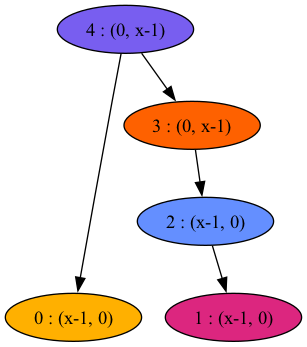

In [2]:
exp.show_morse_graph()

## Morse sets (1D latent)

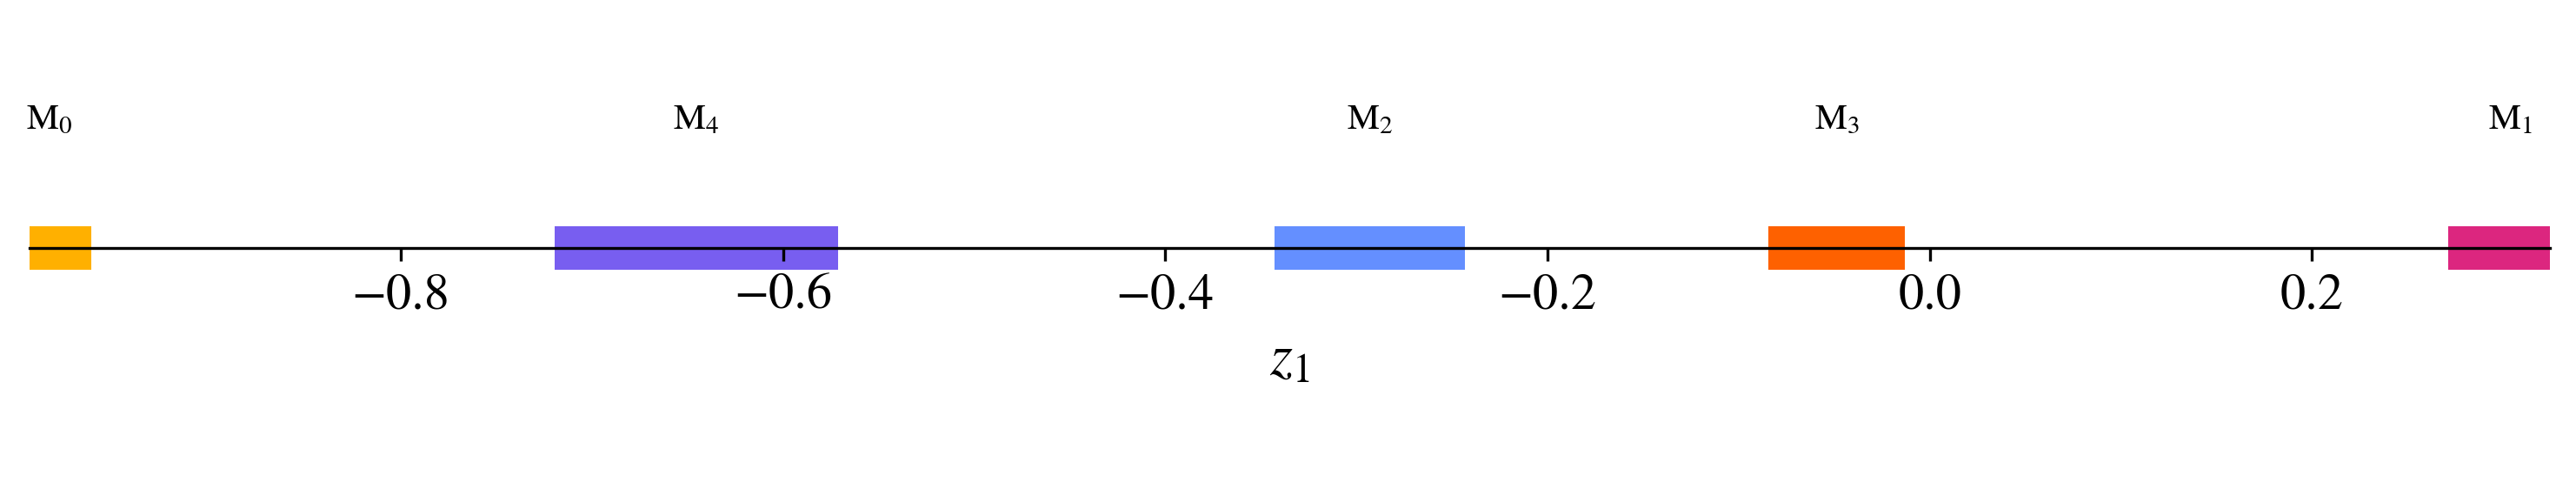

In [3]:
exp.show_morse_sets()

## Final-population histograms (§5.5.2)

Distribution of the total population at the last step of each trajectory: the initial design `D(500, 0, 20)` versus the same set augmented with 300 adaptive samples.

D(500, 0, 20)


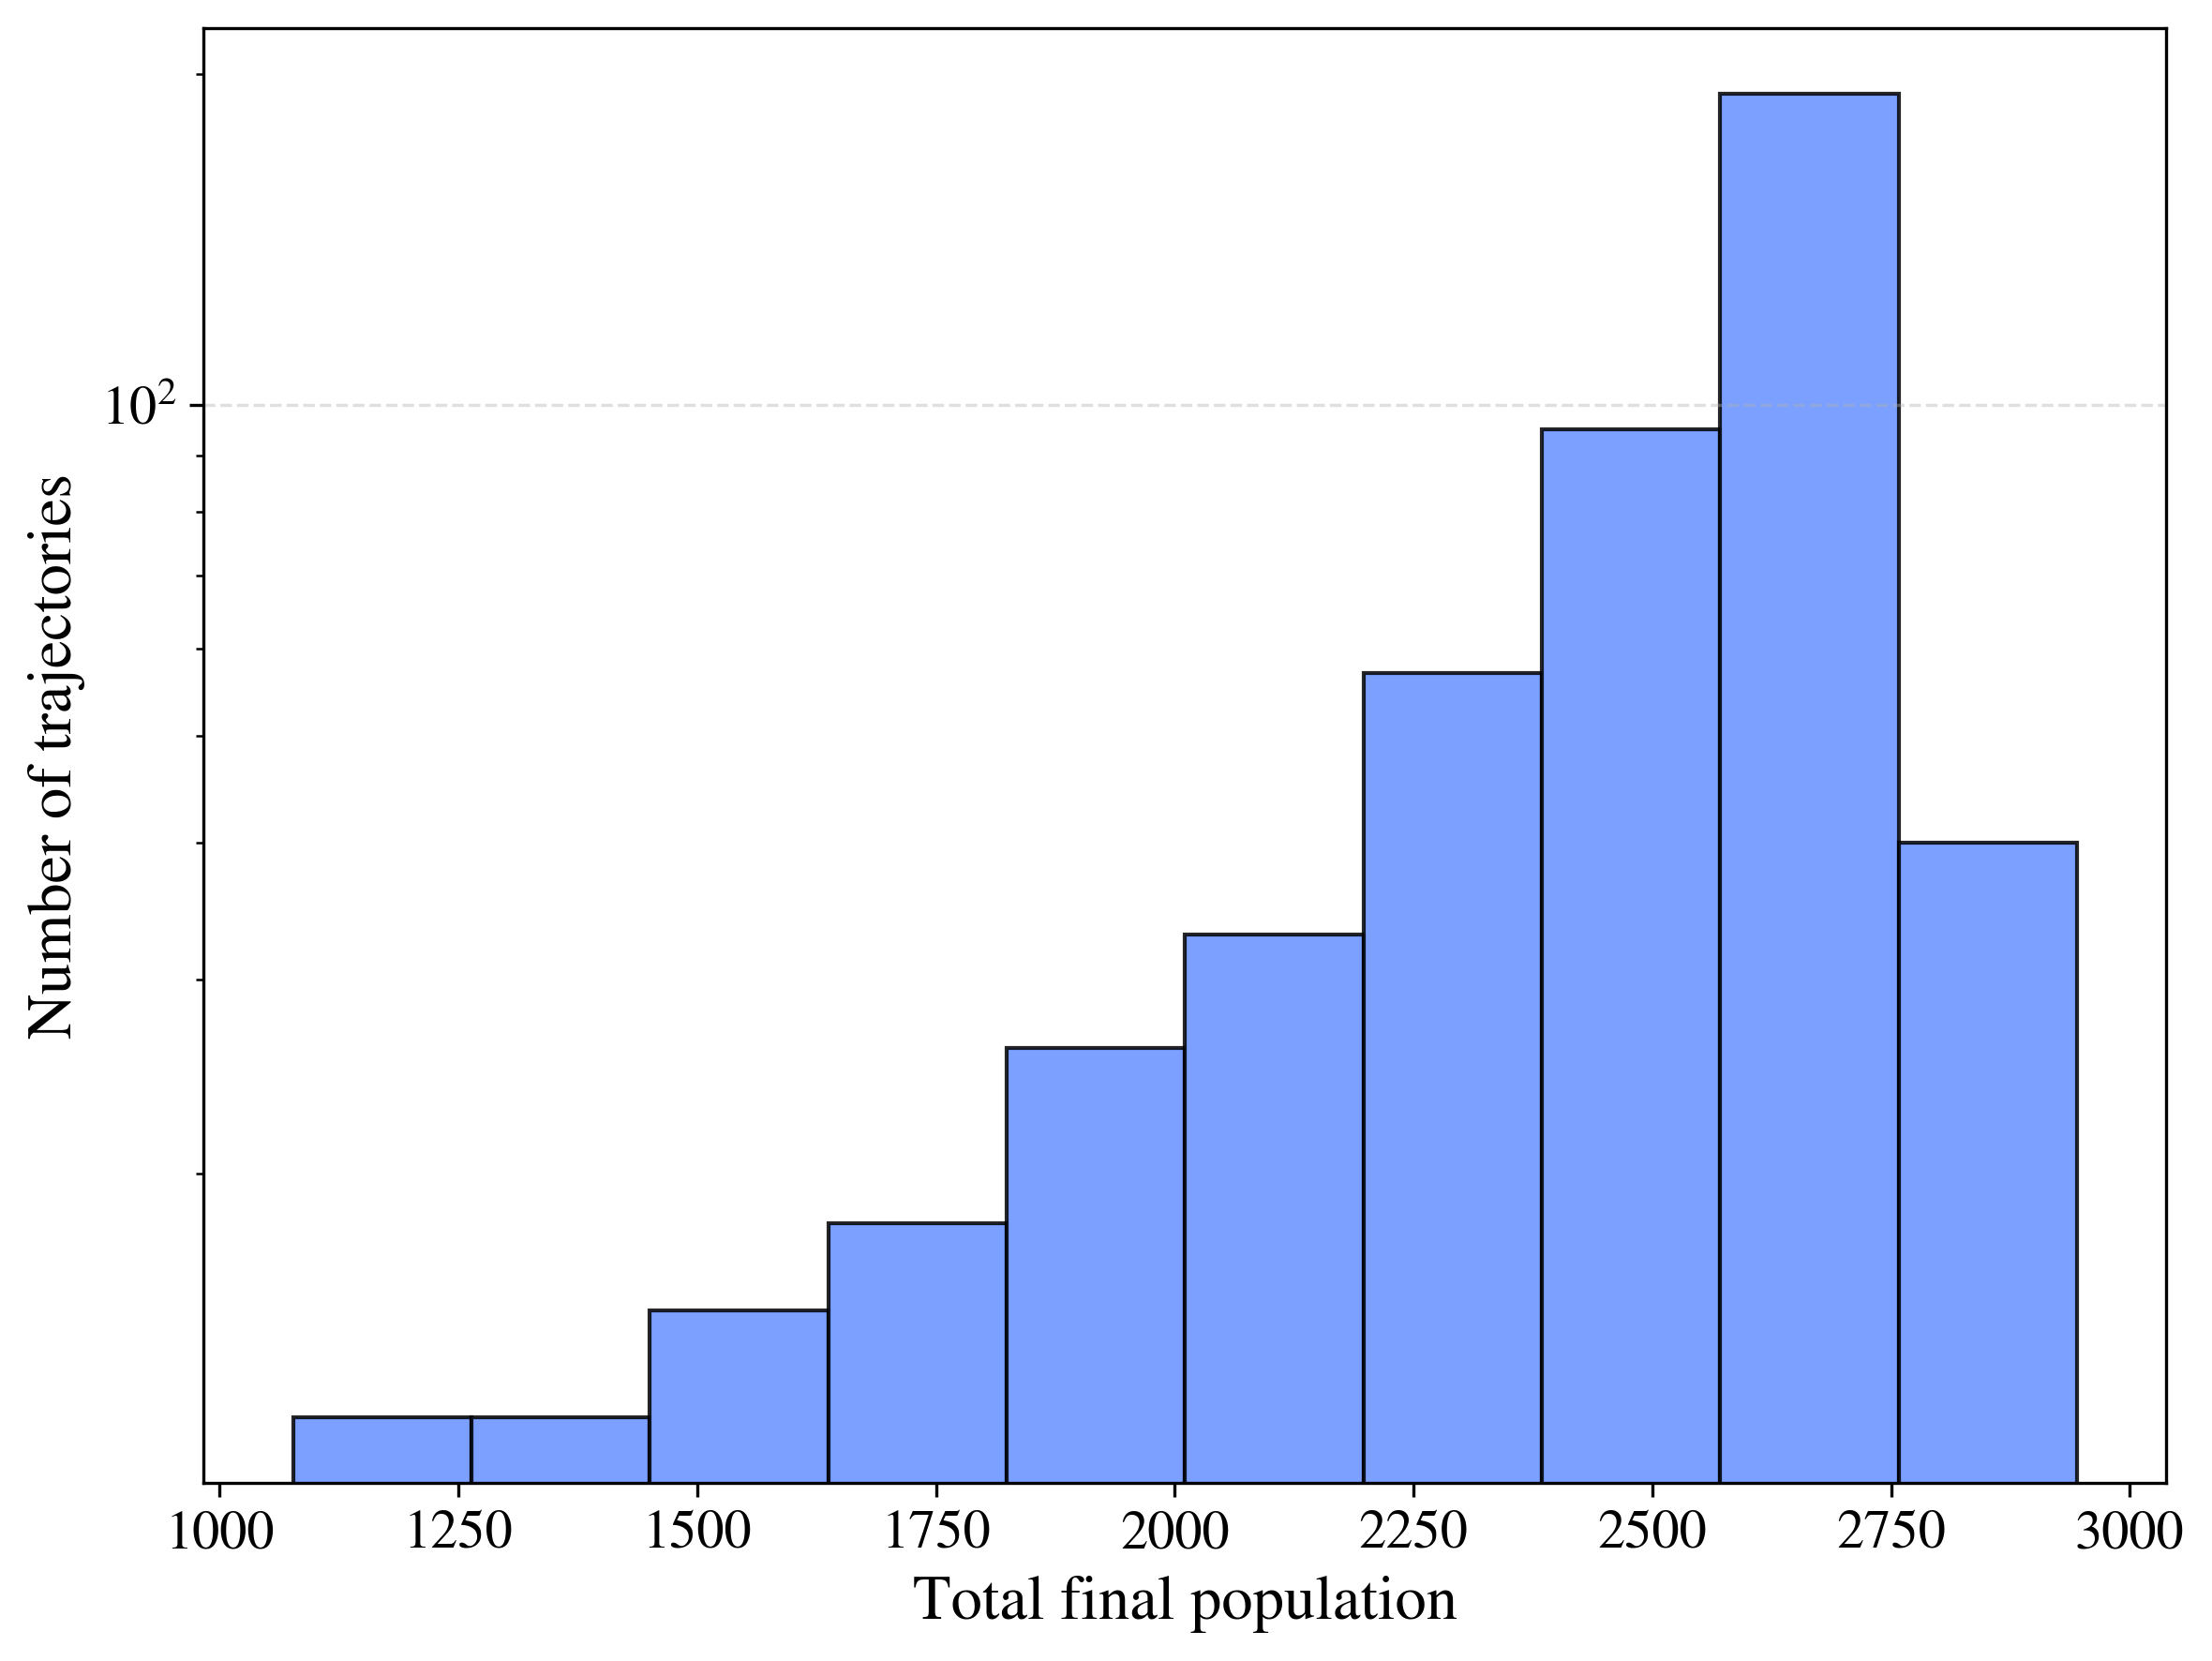

D(500) + 300 adaptive samples


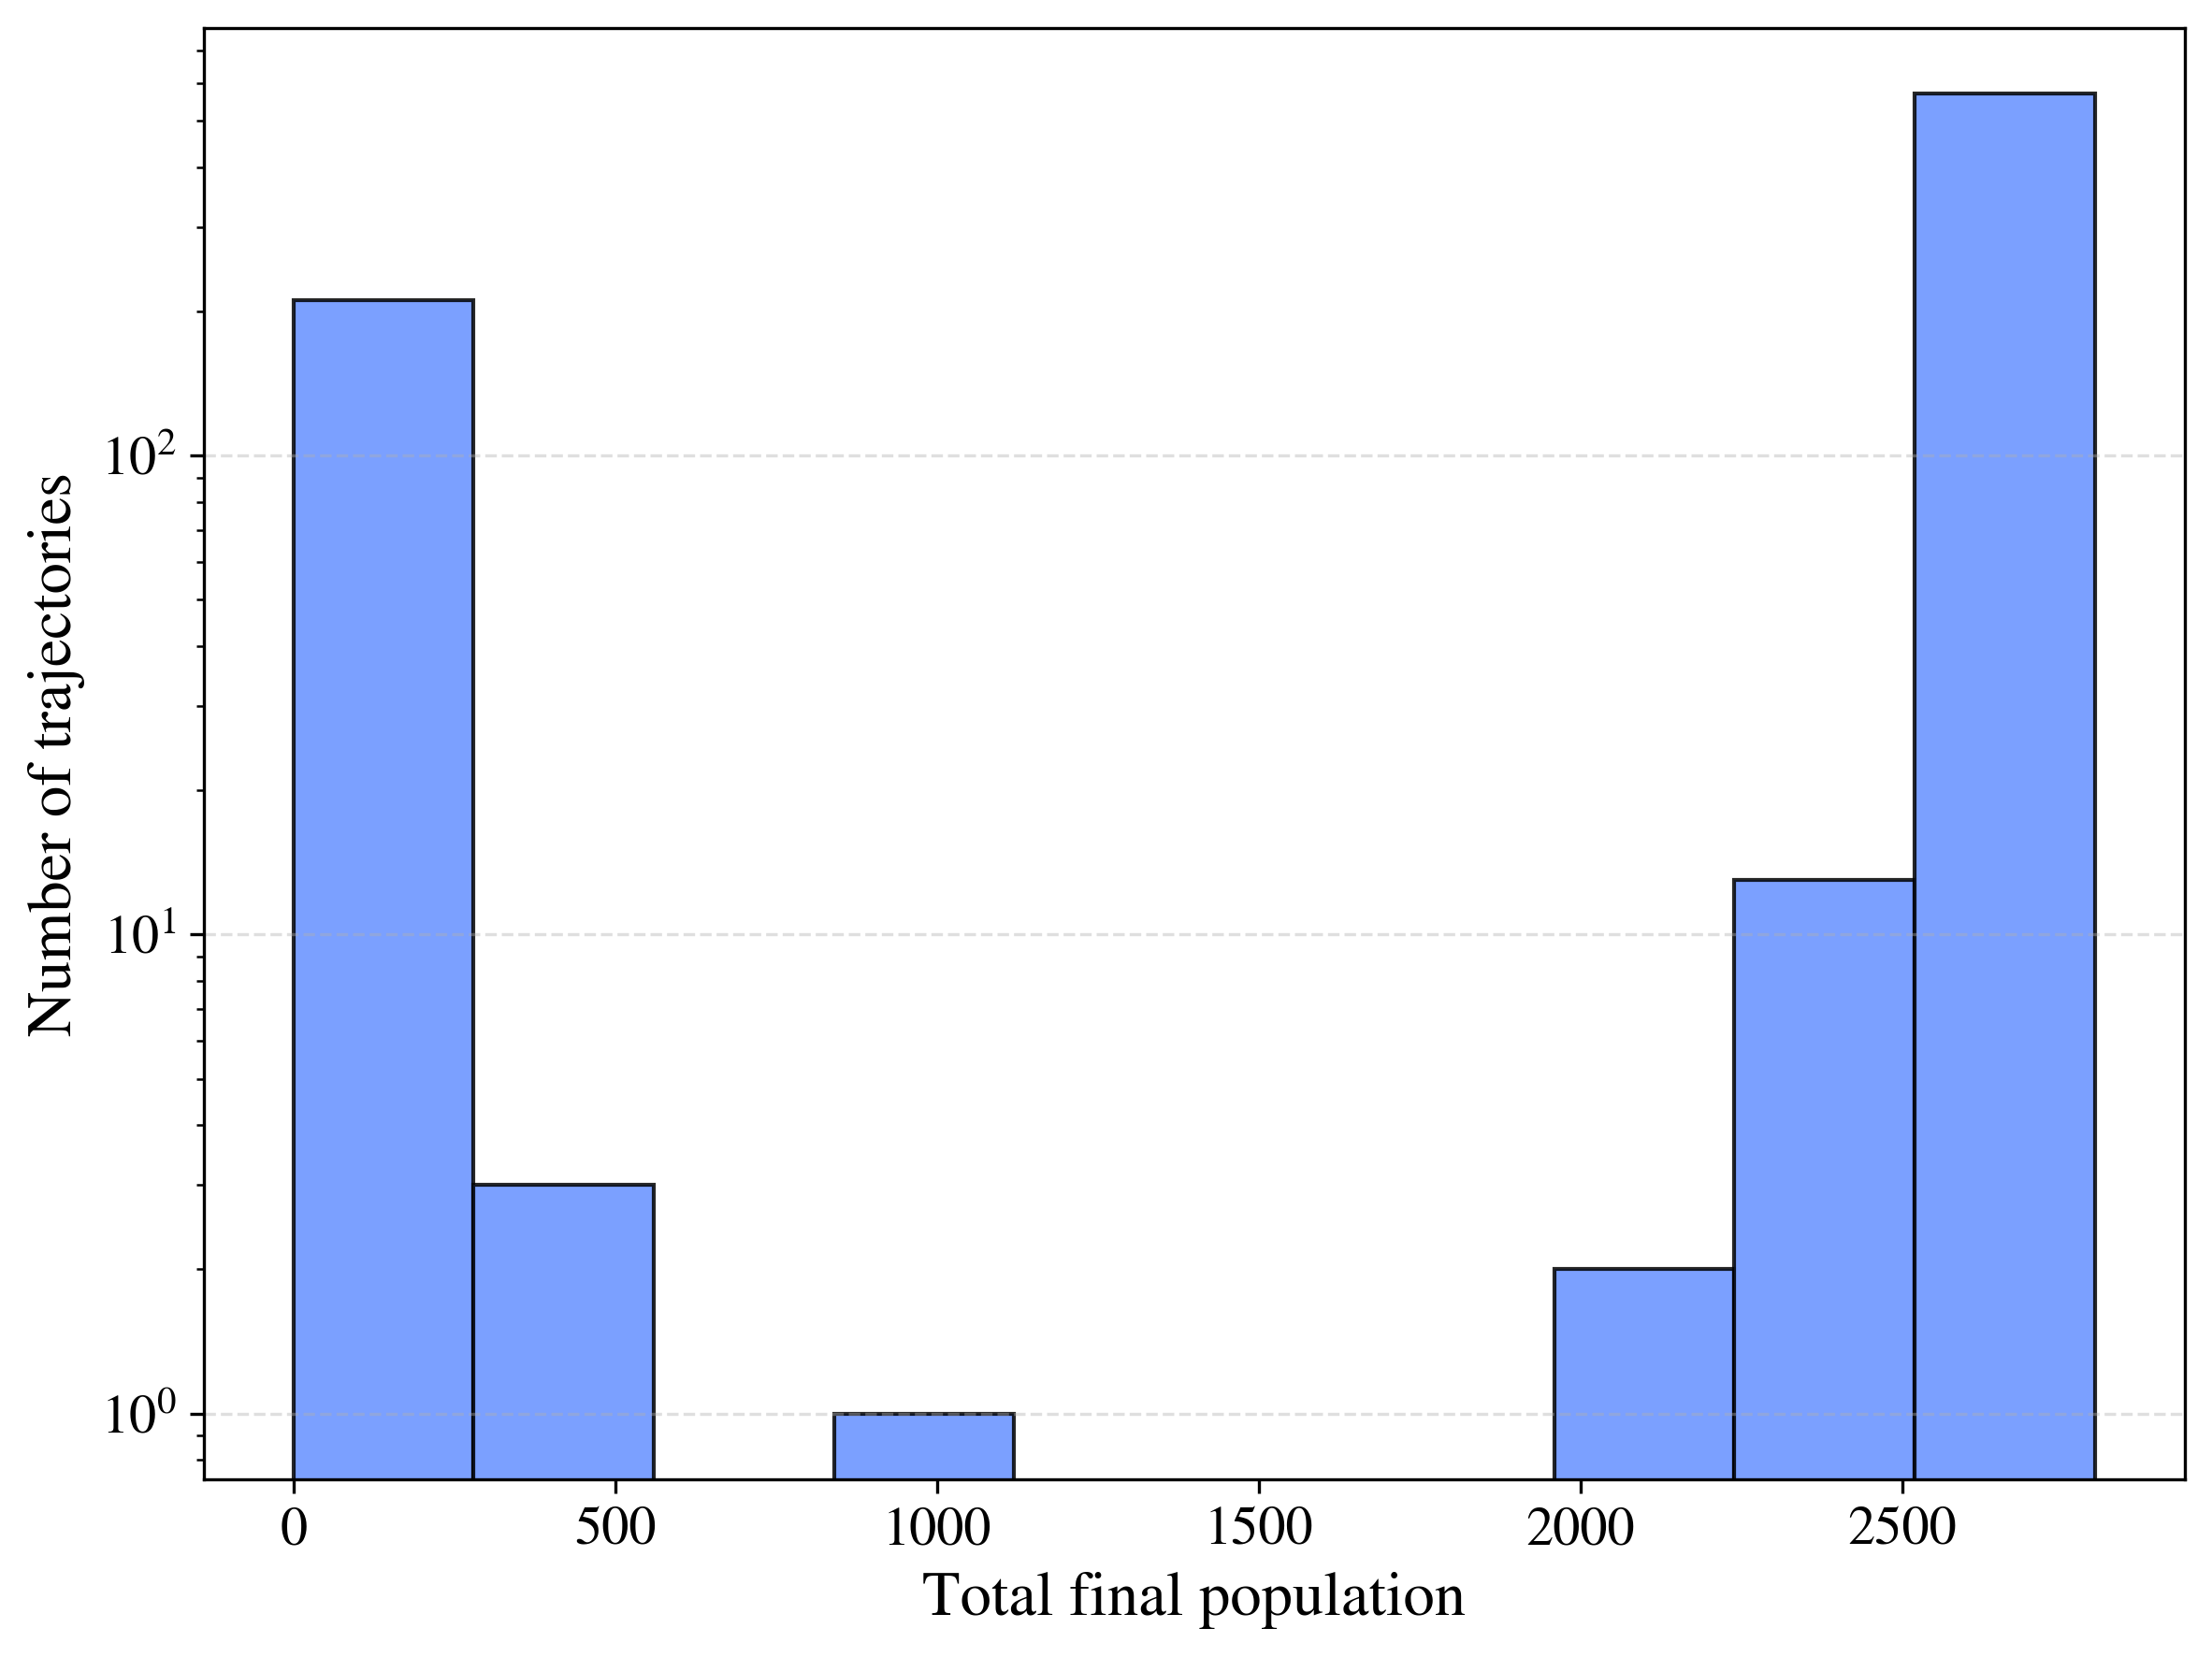

In [4]:
from latentdynamics.viz.histograms import (
    plot_final_population_histogram,
    steps_per_trajectory_from_metadata,
)

out = repo_path("notebooks/rendered/coral")
panels = [
    ("D(500, 0, 20)", repo_path("data/coral"), "train_500"),
    ("D(500) + 300 adaptive samples", repo_path("replay_sources/coral/data/coral"), "train_500_300_adaptive"),
]
for title, data_dir, name in panels:
    steps = steps_per_trajectory_from_metadata(data_dir / f"{name}_metadata.json")
    png = plot_final_population_histogram(
        data_dir / f"{name}.csv", out / f"hist_{name}.png", steps_per_trajectory=steps
    )
    print(title)
    show_image(png, width=560)

## Run provenance

`metrics` reports the §5.5.1 success check: `a0`/`a1` should be `true` (each reference attractor sits in a unique minimal Morse set) and `r` should be `false`.

In [5]:
exp.diagnostics()

{'experiment': 'coral_data_scaling',
 'seed': 0,
 'train_file': 'train_500',
 'dims': '13 -> 1',
 'seed_dir': 'output/coral_data_scaling/train_500/seed_0',
 'final_losses': 'best_epoch: 225\nval_loss_ae1: 2.340415e-02\nval_loss_ae2: 2.009136e-02\nval_loss_dyn: 1.917780e-03\nval_loss_total: 4.368729e-01',
 'mg_params': {'lower_bounds': '[-1.001216173171997]',
  'upper_bounds': '[0.7852622866630554]',
  'subdiv_init': '6',
  'subdiv_min': '8',
  'subdiv_max': '10',
  'subdiv_limit': '10000',
  'bounds_epsilon_frac': '0.01',
  'padding': 'True',
  'box_map_backend': 'auto',
  'bounds_source': 'encoded_data',
  'duration_minutes': '0.0003'},
 'metrics': {'labels': {'a0': 0, 'a1': 1, 'r': None},
  'metrics': {'a0': True, 'a1': True, 'r': False}}}